# 04 - Genetic Algorithm

Los algoritmos geneticos son metaheuristicas poblacionales inspiradas en evolucion. Mantienen una poblacion de soluciones, seleccionan las mejores, recombinan material de dos padres y aplican mutaciones para explorar nuevas regiones.


## 1. Idea general

El ciclo evolutivo basico es:

1. Crear una poblacion inicial.
2. Evaluar la aptitud (*fitness*) de cada individuo.
3. Seleccionar padres con mayor probabilidad si tienen buen fitness.
4. Cruzar padres para crear hijos.
5. Mutar algunos hijos.
6. Repetir durante varias generaciones.

En este notebook el motor **maximiza fitness**. Si el problema original minimiza costo, usamos `fitness = -costo`.


## 2. Codigo base generico

El motor recibe operadores especificos del problema: seleccion, cruce y mutacion. Asi se puede reutilizar para rutas, vectores binarios o variables continuas.


In [1]:
import math
import itertools
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)


def make_tsp_instance(n=20, seed=42):
    """Crea una instancia reproducible de ciudades en el plano [0, 1] x [0, 1]."""
    rng = np.random.default_rng(seed)
    return rng.random((n, 2))


def distance_matrix(coords):
    """Calcula la matriz de distancias euclidianas entre ciudades."""
    diff = coords[:, None, :] - coords[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def tour_length(tour, D):
    """Costo total de una ruta cerrada que vuelve al punto inicial."""
    return float(sum(D[tour[i], tour[(i + 1) % len(tour)]] for i in range(len(tour))))


def plot_tour(coords, tour, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    closed = list(tour) + [tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], marker="o", linewidth=1.8)
    for idx, (x, y) in enumerate(coords):
        ax.text(x + 0.008, y + 0.008, str(idx), fontsize=8)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal", adjustable="box")
    return ax


def plot_convergence(history, title, ylabel="Mejor costo", ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Iteracion")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    return ax


In [2]:
def genetic_algorithm(population, fitness, select, crossover, mutate,
                      n_generations=200, elite_size=2, seed=0):
    """Algoritmo genetico generico que maximiza fitness."""
    rng = np.random.default_rng(seed)
    population = [ind.copy() if hasattr(ind, "copy") else ind for ind in population]
    best = None
    best_fit = -float("inf")
    history = []

    for _ in range(n_generations):
        scores = np.array([fitness(ind) for ind in population], dtype=float)
        order = np.argsort(scores)[::-1]

        if scores[order[0]] > best_fit:
            best_fit = float(scores[order[0]])
            candidate = population[order[0]]
            best = candidate.copy() if hasattr(candidate, "copy") else candidate

        history.append(best_fit)
        new_population = [population[i].copy() if hasattr(population[i], "copy") else population[i]
                          for i in order[:elite_size]]

        while len(new_population) < len(population):
            parent1 = select(population, scores, rng)
            parent2 = select(population, scores, rng)
            child = crossover(parent1, parent2, rng)
            child = mutate(child, rng)
            new_population.append(child)

        population = new_population

    return best, best_fit, history


## 3. Ejemplo: TSP con codificacion por permutacion

Cada individuo es una permutacion de ciudades. El fitness es la distancia negativa, porque el motor maximiza. El cruce usado es **Order Crossover (OX)**, que conserva una subsecuencia de un padre y completa el resto con el orden del otro padre.


In [3]:
coords = make_tsp_instance(n=20, seed=42)
D = distance_matrix(coords)
n = len(coords)
rng = np.random.default_rng(4)
population = [rng.permutation(n) for _ in range(80)]


def tsp_fitness(tour):
    return -tour_length(tour, D)


def tournament_select(population, scores, rng, k=4):
    idx = rng.choice(len(population), size=k, replace=False)
    winner = idx[np.argmax(scores[idx])]
    return population[winner]


def order_crossover(parent1, parent2, rng):
    n = len(parent1)
    a, b = sorted(rng.choice(n, size=2, replace=False))
    child = np.full(n, -1, dtype=int)
    child[a:b] = parent1[a:b]
    fill = [city for city in parent2 if city not in set(child[a:b])]
    positions = [i for i in range(n) if child[i] == -1]
    child[positions] = fill
    return child


def swap_mutation(tour, rng, p=0.25):
    child = tour.copy()
    if rng.random() < p:
        i, j = rng.choice(len(child), size=2, replace=False)
        child[i], child[j] = child[j], child[i]
    return child

best_tour, best_fit, history = genetic_algorithm(
    population, tsp_fitness, tournament_select, order_crossover, swap_mutation,
    n_generations=220, elite_size=3, seed=11
)
best_len = -best_fit

print(f"Mejor longitud encontrada por GA: {best_len:.3f}")
print(f"Ruta: {best_tour.tolist()}")
print(f"Generaciones: {len(history)}")


Mejor longitud encontrada por GA: 3.429
Ruta: [1, 9, 0, 10, 12, 8, 13, 17, 7, 16, 4, 18, 19, 14, 2, 5, 6, 15, 11, 3]
Generaciones: 220


### Explicacion general del codigo ejemplo

1. La poblacion inicial contiene rutas aleatorias.
2. `tournament_select` elige varios candidatos y conserva el de mejor fitness.
3. `order_crossover` crea una ruta valida sin repetir ciudades.
4. `swap_mutation` intercambia dos ciudades para introducir variacion.
5. El elitismo copia directamente las mejores rutas a la siguiente generacion.


<notebook-cell>:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


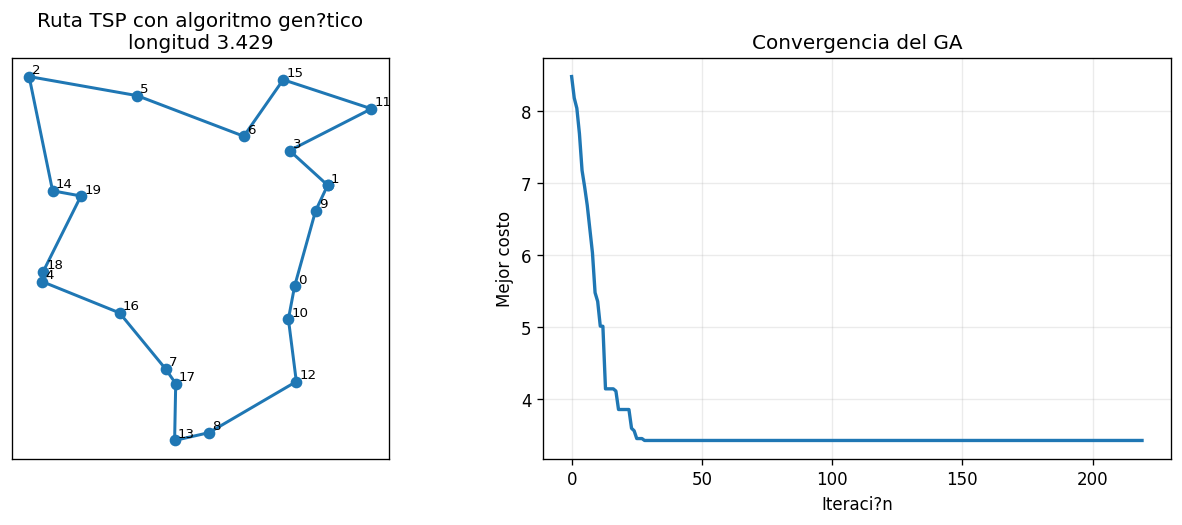

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_tour(coords, best_tour, f"Ruta TSP con algoritmo genetico\nlongitud {best_len:.3f}", ax=axes[0])
plot_convergence([-x for x in history], "Convergencia del GA", ax=axes[1])
plt.tight_layout()
plt.show()


## 4. Parametros, ventajas y limites

El tamano de poblacion controla diversidad; la tasa de mutacion controla exploracion; el elitismo protege buenos hallazgos. Una mutacion muy baja puede estancar la poblacion, mientras que una mutacion muy alta convierte la busqueda en casi aleatoria.
